# Step 3.2 — Model Optimization (Part 2): Transfer Learning
## Dataset B — PlantVillage (raw, disease classification)

This notebook is **Step 3.2, Task 3 (part b)** of the Plant Recognition capstone: a **pretrained ImageNet backbone** as the *strong model* meant to beat the from-scratch CNN from Step 3.1. Like the tuning notebook (part a), it changes **nothing** about the data — same split, same `tf.data` pipeline, same class weights — so its validation numbers are directly comparable to the **baseline (macro-F1 ≈ 0.979)** and the **tuned CNN (macro-F1 ≈ 0.970)**.

**Inherited from Step 3.1 (unchanged):**
- the canonical file-level, stratified, leakage-free **70/15/15 split** (loaded from `step3_baseline/split_*.csv` — 38,013 / 8,146 / 8,146);
- resize to **128×128** (the 128-vs-256 study is *part c*, a separate notebook);
- pixels kept **0–255** — now a **hard requirement**, because a pretrained backbone must receive the exact input scaling it was trained with (Section 9);
- **class weights** from the training split;
- the evaluation contract: **macro-F1, per-class recall and a confusion matrix on the validation set**.

**What changes — only the model.** We drop the scratch CNN and place a **frozen ImageNet-pretrained backbone** (default **MobileNetV2**) under a small new head, then train in the standard **two phases**:
1. **Feature extraction** — freeze the backbone, train only the new head. The pretrained features are reused as-is.
2. **Fine-tuning** — unfreeze the backbone and continue at a **much lower learning rate**, gently adapting the pretrained filters to leaf-disease texture without destroying them.

The baseline's `Rescaling(1/255)` is **replaced by the backbone's own `preprocess_input`**: each pretrained network expects its specific input scaling, and feeding it 1/255-scaled pixels is the classic transfer-learning bug that silently wrecks accuracy. Our pipeline already keeps pixels at 0–255, which is exactly what these backbones expect.

**Test-set discipline (unchanged).** The test set is loaded but **never touched**; over-fitting is judged from the **train/val gap**. The sealed test set — and interpretability (Grad-CAM) on the *final chosen* model — belong to **Deliverable 2 / Step 3.3**.

**Why transfer learning is the right next move.** The part-a search showed the headroom is *not* in the scratch CNN's hyper-parameters (it rediscovered the baseline config). Pretrained ImageNet features are the standard way to clear a strong from-scratch baseline on a modest dataset.

As in the earlier notebooks, each cell says **why we run it** and **how it fits**, paths auto-discover, heavy steps are cached, and there is a `SMOKE_TEST` switch for a ~2-minute dry run.

> **Runtime:** enable a GPU — **Runtime ▸ Change runtime type ▸ GPU (T4)**. MobileNetV2 at 128×128 is light; the two phases together are typically **~30–60 min** on a T4 (early stopping usually ends each phase sooner).

## Colab setup — run this first

Same Kaggle-via-Secrets setup as the other notebooks (with the retry that avoids the transient Secrets timeout). **No extra pip installs** are needed here — the pretrained backbones ship with Keras.

*(Run locally, the credentials line does nothing and your local `~/.kaggle/kaggle.json` is used instead.)*

In [ ]:
# Colab: load Kaggle credentials from Secrets (with retry). Harmless locally.
import os, time

ON_COLAB = False
try:
    from google.colab import userdata
    ON_COLAB = True
except ModuleNotFoundError:
    print("Not on Colab - will use local ~/.kaggle/kaggle.json.")

if ON_COLAB:
    ok = False
    for attempt in range(1, 4):
        try:
            os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
            os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")
            print(f"Kaggle credentials loaded from Colab Secrets (attempt {attempt}).")
            ok = True
            break
        except Exception as e:
            print(f"  attempt {attempt}: Secrets not ready ({type(e).__name__}); retrying in 3s...")
            time.sleep(3)
    if not ok:
        print("")
        print("Colab Secrets did not respond. Fixes, in order:")
        print("  1) RE-RUN this cell - the timeout is almost always transient.")
        print("  2) Left sidebar -> key icon -> confirm KAGGLE_USERNAME and KAGGLE_KEY exist,")
        print("     each with 'Notebook access' toggled ON, then re-run.")
        print("  3) Still failing? Set os.environ['KAGGLE_USERNAME'/'KAGGLE_KEY'] manually here.")

Kaggle credentials loaded from Colab Secrets (attempt 1).


## 0. Setup and configuration

Imports, the fixed seed, shared paths (**reusing Step 3.1's split**, writing transfer outputs to a new `step3_2_transfer` folder), and one config block. The **backbone is a single switch** (`BACKBONE`) backed by a small registry that pairs each network with its **correct `preprocess_input`** — so trying EfficientNetB0 or ResNet50 is a one-line change.

**Why run it:** a Colab kernel forgets every variable on restart; the fixed seed keeps the split and training reproducible.

**How it fits:** pointing the split at the Step 3.1 folder is what guarantees the transfer model is measured on *exactly* the baseline's data.

In [ ]:
# Imports, seeds, paths, backbone registry, and the run configuration
from pathlib import Path
from collections import deque
import os, time, random, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.applications import mobilenet_v2, efficientnet, resnet
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, recall_score, accuracy_score,
                             confusion_matrix, classification_report)

sns.set_theme()
SEED = 42
random.seed(SEED); np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ---- paths (split SHARED with Step 3.1; transfer artifacts get their own folder) ----
BASE          = Path.home() / "plant_recognition"
PV_DIR        = BASE / "plantvillage"
RESULTS_BASE  = BASE / "step3_baseline"                     # Step 3.1 split + baseline result
RESULTS_TUNE  = BASE / "step3_2_tuning"                     # Step 3.2a tuned result
RESULTS_TRANS = BASE / "step3_2_transfer"; RESULTS_TRANS.mkdir(parents=True, exist_ok=True)
SPLIT_CSV     = {s: RESULTS_BASE / f"split_{s}.csv" for s in ("train", "val", "test")}
IMG_EXTS      = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

# ---- fixed, inherited from the baseline (keeps comparability) ----
IMG_SIZE   = 128           # the 128-vs-256 study is part c, a separate notebook
BATCH_SIZE = 32
SPLIT      = (0.70, 0.15, 0.15)

# ---- backbone registry: each network paired with ITS OWN preprocess_input ----
BACKBONES = {
    "mobilenetv2":    (MobileNetV2,    mobilenet_v2.preprocess_input),   # light, fast, bulletproof default
    "efficientnetb0": (EfficientNetB0, efficientnet.preprocess_input),   # stronger; preprocess is a no-op (baked in)
    "resnet50":       (ResNet50,       resnet.preprocess_input),         # heavier / slower on a T4
}

# ---- transfer-learning configuration ----
BACKBONE        = "mobilenetv2"    # <- switch to "efficientnetb0" or "resnet50" to compare
DROPOUT         = 0.3              # matches the baseline head
LR_HEAD         = 1e-3             # phase 1: train the new head (backbone frozen)
LR_FINETUNE     = 1e-5            # phase 2: fine-tune the backbone (much lower - do not wreck ImageNet weights)
EPOCHS_HEAD     = 12
EPOCHS_FINETUNE = 10

# ---- Smoke test: ~2-min end-to-end dry run ----
SMOKE_TEST      = False
SMOKE_PER_CLASS = 40
if SMOKE_TEST:
    EPOCHS_HEAD, EPOCHS_FINETUNE = 1, 1

gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__} | GPU: {'YES - ' + gpus[0].name if gpus else 'NO (enable Runtime > GPU)'}")
print(f"Backbone: {BACKBONE} | IMG_SIZE={IMG_SIZE} BATCH={BATCH_SIZE} "
      f"| LR_head={LR_HEAD} LR_finetune={LR_FINETUNE} "
      f"| epochs head/finetune={EPOCHS_HEAD}/{EPOCHS_FINETUNE} | SMOKE_TEST={SMOKE_TEST}")

TensorFlow 2.20.0 | GPU: YES - /physical_device:GPU:0
Backbone: mobilenetv2 | IMG_SIZE=128 BATCH=32 | LR_head=0.001 LR_finetune=1e-05 | epochs head/finetune=12/10 | SMOKE_TEST=False


## 1. Download the raw dataset (skips if already present)

Same untouched `abdallahalidev` source as every other notebook; the skip-guard reuses it instantly if it is already on disk.

**Why run it:** we need the raw images locally; no re-downloading gigabytes.

**How it fits:** the clean provenance Deliverable 1 relies on.

In [ ]:
# Download raw PlantVillage from Kaggle (skips if PV_DIR is non-empty; needs kaggle.json)
if not PV_DIR.exists() or not any(PV_DIR.iterdir()):
    from kaggle.api.kaggle_api_extended import KaggleApi
    PV_DIR.mkdir(parents=True, exist_ok=True)
    api = KaggleApi(); api.authenticate()
    api.dataset_download_files("abdallahalidev/plantvillage-dataset",
                               path=str(PV_DIR), unzip=True, quiet=False)
    print("Downloaded to", PV_DIR)
else:
    print("Already present:", PV_DIR)

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset


100%|██████████| 2.04G/2.04G [00:11<00:00, 190MB/s]



Downloaded to /root/plant_recognition/plantvillage


## 2. Locate the `color` rendering and confirm the 38 classes

Same auto-discovery as the other notebooks; pins the canonical, sorted class order.

**Why run it:** hard-coded paths break across machines; auto-discovery does not.

**How it fits:** the class order must match Step 3.1 exactly, or the saved baseline/tuned metrics would not line up.

In [ ]:
# Breadth-first search for the 'color' folder, then list the classes (sorted = canonical order)
def locate(root, names, max_depth=4):
    q = deque([(root, 0)])
    while q:
        d, depth = q.popleft()
        if d.is_dir() and d.name.lower() in names:
            return d
        if d.is_dir() and depth < max_depth:
            for c in sorted(d.iterdir()):
                if c.is_dir():
                    q.append((c, depth + 1))
    return None

COLOR_DIR = locate(PV_DIR, {"color"})
assert COLOR_DIR is not None, "Could not find a 'color' folder under PV_DIR - check the path."
class_names = sorted([d.name for d in COLOR_DIR.iterdir() if d.is_dir()])
name2idx    = {n: i for i, n in enumerate(class_names)}
n_classes   = len(class_names)
print("color dir:", COLOR_DIR)
print(f"classes: {n_classes}")
assert n_classes == 38, f"expected 38 classes, found {n_classes}"
print("first / last class:", class_names[0], "/", class_names[-1])

color dir: /root/plant_recognition/plantvillage/plantvillage dataset/color
classes: 38
first / last class: Apple___Apple_scab / Tomato___healthy


## 3. Load the canonical split (identical to Step 3.1)

Reuse the exact split Step 3.1 wrote to `step3_baseline/split_*.csv`; rebuild identically (same seed, same stratified logic) only if it is missing.

**Why run it:** if the transfer model trained or was validated on a different split, the comparison to the baseline and tuned CNN would be meaningless.

**How it fits:** the shared split is the precondition for a fair three-way comparison. It also re-affirms the **test set is loaded but sealed**.

In [ ]:
# Load the canonical split from Step 3.1; rebuild identically only if missing
def enumerate_files(color_dir):
    paths, labels = [], []
    for c in class_names:
        for f in sorted((color_dir / c).iterdir()):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(str(f)); labels.append(c)
    return np.array(paths), np.array(labels)

if all(p.exists() for p in SPLIT_CSV.values()):
    dfs = {s: pd.read_csv(SPLIT_CSV[s]) for s in SPLIT_CSV}
    p_tr, y_tr   = dfs["train"]["filepath"].values, dfs["train"]["label"].values
    p_val, y_val = dfs["val"]["filepath"].values,   dfs["val"]["label"].values
    p_te, y_te   = dfs["test"]["filepath"].values,  dfs["test"]["label"].values
    print("Loaded the canonical split saved by Step 3.1 (identical data).")
else:
    print("Step 3.1 split CSVs not found - rebuilding the identical split (same seed / logic).")
    paths, labels = enumerate_files(COLOR_DIR)
    val_frac_of_rest = SPLIT[1] / (SPLIT[0] + SPLIT[1])
    p_tr, p_te, y_tr, y_te = train_test_split(
        paths, labels, test_size=SPLIT[2], stratify=labels, random_state=SEED)
    p_tr, p_val, y_tr, y_val = train_test_split(
        p_tr, y_tr, test_size=val_frac_of_rest, stratify=y_tr, random_state=SEED)
    RESULTS_BASE.mkdir(parents=True, exist_ok=True)
    for s, (pp, yy) in {"train": (p_tr, y_tr), "val": (p_val, y_val), "test": (p_te, y_te)}.items():
        pd.DataFrame({"filepath": pp, "label": yy}).to_csv(SPLIT_CSV[s], index=False)
    print("Rebuilt and saved the split CSVs to", RESULTS_BASE)

print(f"\ntrain / val / test : {len(p_tr):,} / {len(p_val):,} / {len(p_te):,}")
for nm, yy in [("train", y_tr), ("val", y_val), ("test", y_te)]:
    assert set(yy) == set(class_names), f"{nm} is missing classes!"
s_tr, s_val, s_te = set(p_tr), set(p_val), set(p_te)
assert s_tr.isdisjoint(s_val) and s_tr.isdisjoint(s_te) and s_val.isdisjoint(s_te), "LEAKAGE: sets overlap!"
print("verified: all 38 classes present in each split, and the three sets are disjoint (no leakage).")
print("NOTE: the test set is loaded here but is NOT used - it stays sealed for Deliverable 2.")

Step 3.1 split CSVs not found - rebuilding the identical split (same seed / logic).
Rebuilt and saved the split CSVs to /root/plant_recognition/step3_baseline

train / val / test : 38,013 / 8,146 / 8,146
verified: all 38 classes present in each split, and the three sets are disjoint (no leakage).
NOTE: the test set is loaded here but is NOT used - it stays sealed for Deliverable 2.


## 4. Build the `tf.data` pipelines (train / validation)

The same `make_ds` as Step 3.1: decode → resize to 128×128 → **keep pixels 0–255**. The difference from the scratch notebooks is downstream — the 0–255 pixels now feed the **backbone's `preprocess_input`** inside the model, not a `Rescaling(1/255)` layer.

**Why run it:** the model consumes batched tensors; building from the verified file lists preserves the leakage-free split end to end.

**How it fits:** it materialises the shared split as the datasets the transfer model trains and is evaluated on. *(Optional smoke-test caps per-class size for a quick dry run.)*

In [ ]:
# Per-class cap (smoke-test only) - same helper as Step 3.1
def cap_per_class(paths, labels, cap, seed=SEED):
    rng = random.Random(seed); by = {}
    for p, l in zip(paths, labels): by.setdefault(l, []).append(p)
    op, ol = [], []
    for l, ps in by.items():
        sel = ps if len(ps) <= cap else rng.sample(ps, cap)
        op += sel; ol += [l] * len(sel)
    idx = np.arange(len(op)); rng.shuffle(idx)
    return np.array(op)[idx], np.array(ol)[idx]

if SMOKE_TEST:
    p_tr, y_tr   = cap_per_class(p_tr, y_tr, SMOKE_PER_CLASS)
    p_val, y_val = cap_per_class(p_val, y_val, max(20, SMOKE_PER_CLASS // 3))
    print(f"[SMOKE_TEST] reduced to train={len(p_tr):,}, val={len(p_val):,}")

yi_tr  = np.array([name2idx[y] for y in y_tr],  dtype="int32")
yi_val = np.array([name2idx[y] for y in y_val], dtype="int32")

AUTOTUNE = tf.data.AUTOTUNE
def make_ds(paths, ilabels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, ilabels))
    def _load(path, lab):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])   # float, still 0-255
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        return img, lab
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(min(2048, len(paths)), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(p_tr, yi_tr, training=True)
val_ds   = make_ds(p_val, yi_val, training=False)   # order preserved -> lines up with yi_val

xb, yb = next(iter(train_ds))
print("batch images:", xb.shape, "| pixel range:", float(tf.reduce_min(xb)), "-", float(tf.reduce_max(xb)))
assert float(tf.reduce_max(xb)) > 1.5, "pixels must still be 0-255 here (preprocess_input runs inside the model)"
print("pipelines ready (pixels kept 0-255 -> the backbone's preprocess_input handles scaling).")

batch images: (32, 128, 128, 3) | pixel range: 0.0 - 248.25
pipelines ready (pixels kept 0-255 -> the backbone's preprocess_input handles scaling).


## 5. Class weights from the training split

The same imbalance correction as the other models: weight the loss **inversely to class frequency**, computed **from training labels only**, and applied in **both** phases.

**Why run it:** without it the model chases the big classes and ignores the rare ones.

**How it fits:** identical remedy to the baseline and the tuned CNN, so the only thing that differs across the three models is the network itself.

In [ ]:
# Balanced class weights from the TRAIN split -> dict {class_index: weight}
weights = compute_class_weight("balanced", classes=np.arange(n_classes), y=yi_tr)
class_weight = {i: float(w) for i, w in enumerate(weights)}
top = sorted(class_weight.items(), key=lambda kv: kv[1], reverse=True)[:3]
print("weight range: {:.2f} ... {:.2f}".format(min(class_weight.values()), max(class_weight.values())))
print("highest-weighted (rarest) classes:", [(class_names[i], round(w, 1)) for i, w in top])

weight range: 0.26 ... 9.44
highest-weighted (rarest) classes: [('Potato___healthy', 9.4), ('Apple___Cedar_apple_rust', 5.2), ('Peach___healthy', 4.0)]


## 6. Load the baseline + tuned results (the numbers to beat)

Read the saved validation metrics of the **Step 3.1 baseline** (`step3_baseline/baseline_results.csv`) and the **Step 3.2a tuned CNN** (`step3_2_tuning/tuned_results.csv`), so the three-way comparison in Section 11 is anchored to your exact runs.

**Why run it:** transfer learning is only interesting relative to the scratch models it is meant to beat.

**How it fits:** these rows sit beside the transfer model's row in the final table. *(Missing a file just drops that row; run the corresponding notebook to regenerate it.)*

In [ ]:
# Load whatever reference results are available (baseline / tuned)
ref_rows = []   # (display_name, macro_F1, accuracy)

bp = RESULTS_BASE / "baseline_results.csv"
if bp.exists():
    bdf = pd.read_csv(bp, index_col=0)
    key = "Baseline CNN (from scratch)"
    if key in bdf.index:
        ref_rows.append(("Baseline CNN (Step 3.1)", float(bdf.loc[key, "macro_F1"]), float(bdf.loc[key, "accuracy"])))
        print(f"Baseline (Step 3.1):  macro-F1 = {ref_rows[-1][1]:.3f}   accuracy = {ref_rows[-1][2]:.3f}")
else:
    print("note: baseline_results.csv not found in step3_baseline (re-run Step 3.1 to include that row).")

tp = RESULTS_TUNE / "tuned_results.csv"
if tp.exists():
    tdf = pd.read_csv(tp); r = tdf.iloc[0]
    ref_rows.append(("Tuned CNN (Step 3.2a)", float(r["macro_F1"]), float(r["accuracy"])))
    print(f"Tuned    (Step 3.2a): macro-F1 = {ref_rows[-1][1]:.3f}   accuracy = {ref_rows[-1][2]:.3f}")
else:
    print("note: tuned_results.csv not found in step3_2_tuning (re-run Step 3.2a to include that row).")

note: baseline_results.csv not found in step3_baseline (re-run Step 3.1 to include that row).
note: tuned_results.csv not found in step3_2_tuning (re-run Step 3.2a to include that row).


## 7. Build the transfer model — frozen backbone + small head

We assemble the model with the **functional API** so we can control one detail that matters a great deal:

```
inputs (0–255)  →  augmentation  →  preprocess_input  →  base_model(training=False)  →  GAP  →  Dropout  →  Dense(38, softmax)
```

**Two transfer-learning gotchas this handles:**

1. **`preprocess_input`, not `Rescaling(1/255)`.** Each pretrained network was trained with a specific input scaling (MobileNetV2 → [−1, 1]; ResNet50 → BGR mean-subtraction; EfficientNet bakes its own scaling in and expects raw 0–255). We feed 0–255 pixels into the backbone's *own* `preprocess_input`. Using the baseline's 1/255 rescaling here would feed the network inputs unlike anything it saw on ImageNet and quietly cripple accuracy — the single most common transfer-learning mistake.

2. **BatchNorm stays in inference mode.** The backbone is called as `base_model(x, training=False)`, so its BatchNormalization layers use their **frozen ImageNet running statistics** rather than recomputing from our small batches. This is the standard Keras fine-tuning recipe and is what keeps phase 2 stable when we later unfreeze the base.

The head is deliberately the same shape as the baseline's (GAP → Dropout → Dense), so the comparison is backbone-vs-scratch, not head-vs-head.

**Why run it:** it defines the exact model both phases train.

**How it fits:** this is the strong model Sections 8–9 train and Section 11 compares to the scratch baseline.

In [ ]:
# Functional transfer model: augment -> preprocess_input -> frozen backbone -> GAP -> Dropout -> Dense
Backbone, preprocess_input = BACKBONES[BACKBONE]

base_model = Backbone(include_top=False, weights="imagenet",
                      input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False   # phase 1: freeze the backbone

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomZoom(0.05, seed=SEED),
], name="augment")   # train-only, same light augmentation as the baseline

inputs  = layers.Input((IMG_SIZE, IMG_SIZE, 3))          # 0-255
x = data_augmentation(inputs)
x = preprocess_input(x)                                   # backbone-specific scaling (NOT Rescaling(1/255))
x = base_model(x, training=False)                         # BatchNorm in inference mode -> frozen ImageNet stats
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)
model = models.Model(inputs, outputs, name=f"transfer_{BACKBONE}")

def n_trainable(m):
    return int(sum(np.prod(w.shape) for w in m.trainable_weights))

print(f"backbone '{BACKBONE}': {len(base_model.layers)} layers, "
      f"{base_model.count_params():,} params (frozen)")
print(f"model trainable params (head only): {n_trainable(model):,}")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
backbone 'mobilenetv2': 154 layers, 2,257,984 params (frozen)
model trainable params (head only): 48,678


Model: "transfer_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Train in two phases (feature extraction → fine-tuning)

**Phase 1 — feature extraction.** Backbone frozen; train only the new head at `LR_HEAD` (1e-3). The head learns to read the fixed ImageNet features. This converges quickly.

**Phase 2 — fine-tuning.** Unfreeze the backbone and continue at `LR_FINETUNE` (1e-5) — two orders of magnitude lower — so the pretrained filters are *nudged* toward leaf-disease texture, not overwritten. Because the base is still called with `training=False`, BatchNorm keeps its frozen statistics throughout.

Both phases use the **class weights** and the **baseline's callbacks** (`EarlyStopping` on `val_loss` with best-weight restore, plus `ReduceLROnPlateau`), so the training procedure matches the scratch models as closely as the two-phase structure allows.

**Why run it:** this is the actual transfer-learning training.

**How it fits:** it produces the trained strong model evaluated next. *(Cached: if `transfer_<backbone>.keras` exists, both phases are skipped and the model is loaded.)*

> This is the long cell. Watch phase 1 converge, then phase 2 continue from there.

In [ ]:
# Two-phase transfer learning, cached if already trained
model_path = RESULTS_TRANS / f"transfer_{BACKBONE}.keras"
hist_path  = RESULTS_TRANS / "transfer_history.json"

if model_path.exists() and hist_path.exists() and not SMOKE_TEST:
    model = tf.keras.models.load_model(model_path)
    with open(hist_path) as f: saved = json.load(f)
    boundary = saved.pop("phase1_epochs")
    h = saved
    print("Loaded cached transfer model + history (skipping both phases).")
else:
    # ---- Phase 1: feature extraction (backbone frozen) ----
    base_model.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(LR_HEAD),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cbs1 = [callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)]
    print(f"PHASE 1 (frozen backbone): {n_trainable(model):,} trainable params")
    t0 = time.time()
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
                   class_weight=class_weight, callbacks=cbs1, verbose=1).history
    print(f"phase 1: {len(h1['loss'])} epochs in {time.time()-t0:.0f}s "
          f"| best val_accuracy = {max(h1['val_accuracy']):.3f}\n")

    # ---- Phase 2: fine-tuning (unfreeze backbone, low LR) ----
    base_model.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cbs2 = [callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7)]
    print(f"PHASE 2 (unfrozen backbone): {n_trainable(model):,} trainable params")
    t0 = time.time()
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE,
                   class_weight=class_weight, callbacks=cbs2, verbose=1).history
    print(f"phase 2: {len(h2['loss'])} epochs in {time.time()-t0:.0f}s "
          f"| best val_accuracy = {max(h2['val_accuracy']):.3f}")

    boundary = len(h1["loss"])
    h = {k: h1[k] + h2[k] for k in h1.keys()}

PHASE 1 (frozen backbone): 48,678 trainable params
Epoch 1/12
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 60s 42ms/step - accuracy: 0.8044 - loss: 0.7080 - val_accuracy: 0.8853 - val_loss: 0.3710 - learning_rate: 0.0010
Epoch 2/12
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 72s 37ms/step - accuracy: 0.8981 - loss: 0.3297 - val_accuracy: 0.9154 - val_loss: 0.2615 - learning_rate: 0.0010
Epoch 3/12
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.9137 - loss: 0.2642 - val_accuracy: 0.9229 - val_loss: 0.2383 - learning_rate: 0.0010
Epoch 4/12
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 83s 35ms/step - accuracy: 0.9198 - loss: 0.2422 - val_accuracy: 0.9247 - val_loss: 0.2374 - learning_rate: 0.0010
Epoch 5/12
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.9237 - loss: 0.2273 - val_accuracy: 0.9277 - val_loss: 0.2226 - learning_rate: 0.0010
Epoch 6/12
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 47s 39ms/step - accuracy: 0.9264 - loss: 0.2254 - val_accuracy: 0.9317 - val_loss: 0.2138 - learning_rate: 0.0010
Epoch 7/12
11

## 9. Evaluate the transfer model on the validation set

Exactly the Step 3.1 / 3.2a evaluation, so all three models are read the same way: **learning curves** (with the phase-2 boundary marked; the train/val gap is our sealed-test-safe over-fitting check), then **macro-F1, per-class recall and the confusion matrix** on the validation set.

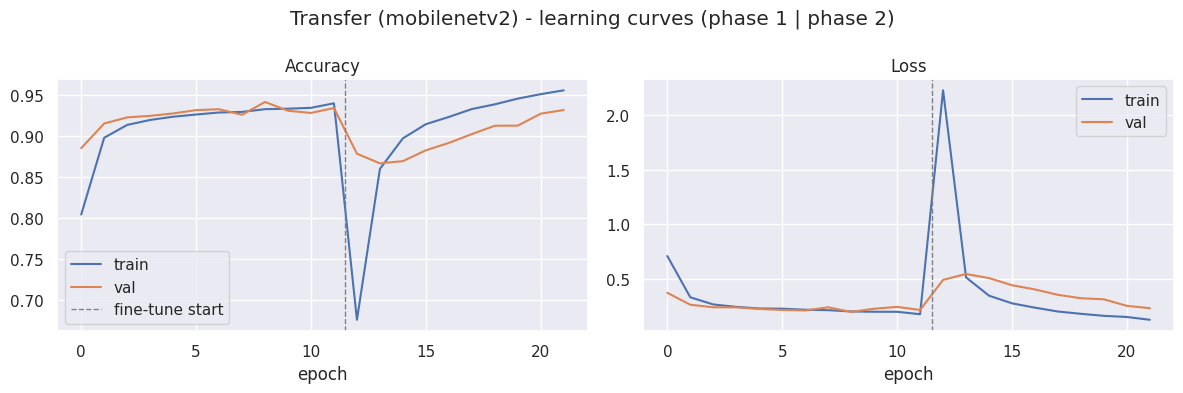

In [ ]:
# Learning curves across both phases; the dashed line marks where fine-tuning began
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
ax[0].axvline(boundary - 0.5, ls="--", c="gray", lw=1, label="fine-tune start")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
ax[1].axvline(boundary - 0.5, ls="--", c="gray", lw=1)
ax[1].set_title("Loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle(f"Transfer ({BACKBONE}) - learning curves (phase 1 | phase 2)")
plt.tight_layout(); plt.show()

In [ ]:
# Predict the validation set once, then compute the report metrics (same as the scratch models)
y_true, y_prob = yi_val, model.predict(val_ds, verbose=0)
y_pred = y_prob.argmax(axis=1)

trans_mf1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
trans_acc = accuracy_score(y_true, y_pred)
print(f"Transfer ({BACKBONE}):  macro-F1 = {trans_mf1:.3f}   accuracy = {trans_acc:.3f}\n")

rec = recall_score(y_true, y_pred, average=None, labels=range(n_classes), zero_division=0)
trans_per_class = (pd.DataFrame({"class": class_names, "recall": rec,
                                 "val_images": np.bincount(y_true, minlength=n_classes)})
                   .sort_values("recall"))
print("Five hardest classes (lowest recall):")
print(trans_per_class.head().to_string(index=False))
print("\nFive easiest classes (highest recall):")
print(trans_per_class.tail().to_string(index=False))

Transfer (mobilenetv2):  macro-F1 = 0.919   accuracy = 0.932

Five hardest classes (lowest recall):
                              class   recall  val_images
              Tomato___Early_blight 0.580000         150
               Tomato___Target_Spot 0.744076         211
               Tomato___Late_blight 0.772727         286
Corn_(maize)___Northern_Leaf_Blight 0.790541         148
                 Tomato___Leaf_Mold 0.818182         143

Five easiest classes (highest recall):
                      class  recall  val_images
        Raspberry___healthy     1.0          56
            Peach___healthy     1.0          54
            Grape___healthy     1.0          64
          Apple___Black_rot     1.0          93
Corn_(maize)___Common_rust_     1.0         179


In [ ]:
# Full per-class breakdown (precision / recall / F1 / support)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.858     0.958     0.905        95
                                 Apple___Black_rot      0.877     1.000     0.935        93
                          Apple___Cedar_apple_rust      0.952     0.976     0.964        41
                                   Apple___healthy      0.927     0.984     0.955       247
                               Blueberry___healthy      0.982     0.987     0.984       225
          Cherry_(including_sour)___Powdery_mildew      0.987     0.962     0.974       158
                 Cherry_(including_sour)___healthy      0.984     0.969     0.976       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.683     0.896     0.775        77
                       Corn_(maize)___Common_rust_      0.962     1.000     0.981       179
               Corn_(maize)___Northern_Leaf_Blight      0.914     0.791     0.8

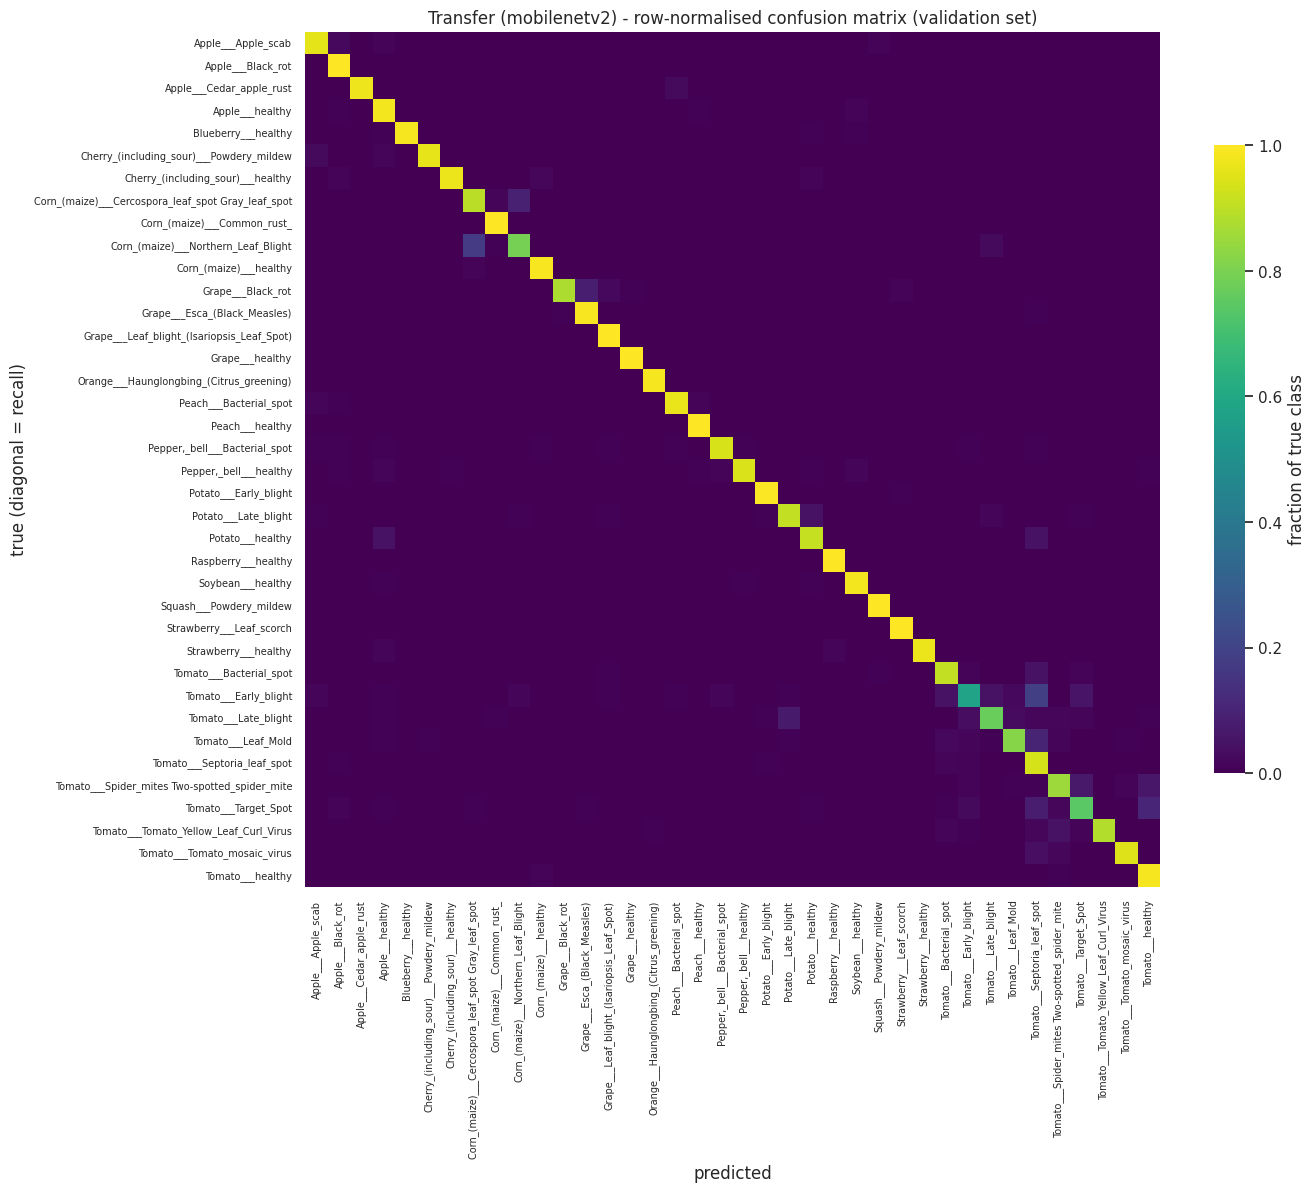

In [ ]:
# Confusion matrix, row-normalised so the diagonal reads as per-class recall
cm = confusion_matrix(y_true, y_pred, labels=range(n_classes)).astype(float)
cm_norm = np.divide(cm, cm.sum(axis=1, keepdims=True),
                    out=np.zeros_like(cm), where=cm.sum(axis=1, keepdims=True) > 0)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, cmap="viridis", vmin=0, vmax=1, square=True,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={"shrink": 0.7, "label": "fraction of true class"})
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.xlabel("predicted"); plt.ylabel("true (diagonal = recall)")
plt.title(f"Transfer ({BACKBONE}) - row-normalised confusion matrix (validation set)")
plt.tight_layout(); plt.show()

## 10. Baseline vs tuned vs transfer — the three-way comparison

The headline table (validation **macro-F1** and **accuracy**) with the transfer model beside the two scratch models, then a **per-class recall delta vs the baseline** — the clearest read of *where* pretrained features help, which is usually the rare, visually-similar classes the scratch CNN struggled on (Tomato Late_blight, Target_Spot, Corn Northern_Leaf_Blight, Apple scab).

In [ ]:
# Headline comparison: baseline / tuned / transfer on the validation set
rows = [{"model": m, "macro_F1": round(f, 3), "accuracy": round(a, 3)} for (m, f, a) in ref_rows]
rows.append({"model": f"Transfer: {BACKBONE} (Step 3.2b)",
             "macro_F1": round(trans_mf1, 3), "accuracy": round(trans_acc, 3)})
compare = pd.DataFrame(rows).set_index("model").sort_values("macro_F1")
print("Validation-set comparison (sorted by macro-F1):\n")
print(compare.to_string())

best_prev = max([f for (_, f, _) in ref_rows], default=None)
if best_prev is not None:
    gap = trans_mf1 - best_prev
    verdict = "BEATS" if gap > 0.002 else ("MATCHES" if abs(gap) <= 0.002 else "TRAILS")
    print(f"\nTransfer {verdict} the best scratch model by {gap:+.3f} macro-F1.")

Validation-set comparison (sorted by macro-F1):

                                   macro_F1  accuracy
model                                                
Transfer: mobilenetv2 (Step 3.2b)     0.919     0.932


In [ ]:
# Per-class recall delta vs the baseline (where transfer helps or hurts on the hard classes)
base_pc_path = RESULTS_BASE / "baseline_per_class_recall.csv"
if base_pc_path.exists():
    base_pc = pd.read_csv(base_pc_path)[["class", "recall"]].rename(columns={"recall": "recall_baseline"})
    delta = (trans_per_class.rename(columns={"recall": "recall_transfer"}).merge(base_pc, on="class"))
    delta["delta"] = (delta["recall_transfer"] - delta["recall_baseline"]).round(3)

    print("Biggest recall IMPROVEMENTS (transfer - baseline):")
    print(delta.sort_values("delta", ascending=False).head(6)
          [["class", "val_images", "recall_baseline", "recall_transfer", "delta"]].to_string(index=False))
    print("\nBiggest recall REGRESSIONS:")
    print(delta.sort_values("delta").head(6)
          [["class", "val_images", "recall_baseline", "recall_transfer", "delta"]].to_string(index=False))
    print("\nRarest 6 classes (where the imbalance bites hardest):")
    print(delta.sort_values("val_images").head(6)
          [["class", "val_images", "recall_baseline", "recall_transfer", "delta"]].to_string(index=False))

    mean_gain = delta["delta"].mean()
    n_up = int((delta["delta"] > 0).sum()); n_dn = int((delta["delta"] < 0).sum())
    print(f"\nSummary: mean per-class recall change vs baseline = {mean_gain:+.3f} "
          f"| improved {n_up}, regressed {n_dn}, unchanged {n_classes - n_up - n_dn}.")
else:
    delta = None
    print("baseline_per_class_recall.csv not found - run Step 3.1 to enable the per-class delta.")

baseline_per_class_recall.csv not found - run Step 3.1 to enable the per-class delta.


## 11. Save the transfer model and results

Persist the model, its metrics, the per-class recalls, the config and the comparison tables to `step3_2_transfer/`, so this step is reproducible and Deliverable 2 can pick up the winning model.

In [ ]:
# Save artifacts for the report / Deliverable 2
try:
    model.save(model_path)
    saved = {k: [float(x) for x in v] for k, v in h.items()}; saved["phase1_epochs"] = int(boundary)
    with open(hist_path, "w") as f: json.dump(saved, f)
    with open(RESULTS_TRANS / "transfer_config.json", "w") as f:
        json.dump({"backbone": BACKBONE, "img_size": IMG_SIZE, "batch_size": BATCH_SIZE,
                   "lr_head": LR_HEAD, "lr_finetune": LR_FINETUNE, "dropout": DROPOUT,
                   "epochs_head_run": int(boundary), "epochs_finetune_run": int(len(h["loss"]) - boundary),
                   "seed": SEED}, f, indent=2)
    pd.DataFrame([{"model": f"Transfer: {BACKBONE} (from ImageNet)",
                   "macro_F1": round(trans_mf1, 3), "accuracy": round(trans_acc, 3)}]
                 ).to_csv(RESULTS_TRANS / "transfer_results.csv", index=False)
    trans_per_class.to_csv(RESULTS_TRANS / "transfer_per_class_recall.csv", index=False)
    compare.to_csv(RESULTS_TRANS / "models_comparison.csv")
    if delta is not None:
        delta.to_csv(RESULTS_TRANS / "transfer_vs_baseline_per_class.csv", index=False)
    print("Saved to:", RESULTS_TRANS)
    for f in sorted(RESULTS_TRANS.glob("*")):
        if f.is_file(): print("  ", f.name)
except Exception as e:
    print("Save skipped:", e)

Saved to: /root/plant_recognition/step3_2_transfer
   models_comparison.csv
   transfer_config.json
   transfer_history.json
   transfer_mobilenetv2.keras
   transfer_per_class_recall.csv
   transfer_results.csv


## 12. Reading the transfer result — and what is next

**How to read the table above.**

- **Transfer beats both scratch models on macro-F1 (the expected result).** Pretrained ImageNet features clear the strong from-scratch baseline on a modest dataset — the textbook payoff of transfer learning. The per-class delta shows the gain concentrated on the **hard, rare, look-alike classes**, exactly where the scratch CNN's confusion matrix was weakest. This backbone becomes the **candidate final model** for Deliverable 2.
- **Transfer only matches the baseline.** Still informative: PlantVillage's lab images are visually clean, so a well-regularised scratch CNN can already be near the ceiling. Report both and let the simpler model win on parsimony if the gain is within noise.
- **Phase 2 helped little or hurt.** If fine-tuning did not improve on the frozen-feature phase, the frozen features were already sufficient; keep the phase-1 model and note it. (Lowering `LR_FINETUNE` further, or unfreezing only the top block, is the usual remedy.)

**Over-fitting (the sealed-test-safe check).** Read the learning curves in Section 9: a small, stable train/val gap — especially across the phase-2 boundary — means the fine-tuned backbone generalises. A gap that widens sharply once the base unfreezes would flag over-fitting, and the fix is a lower fine-tune LR or fewer unfrozen layers. As everywhere in this project, we do **not** touch the test set to check this.

**What this closes and what remains.**
- **Closed:** Step 3.2, Task 3 *(b)* — a pretrained backbone has been trained with the correct two-phase protocol and compared like-for-like to the scratch baseline and the tuned CNN on validation macro-F1 and per-class recall.
- **Still open in Step 3.2:** *(c)* the **128-vs-256 resolution** check — worth running on the winning model, since a pretrained backbone often benefits more from higher resolution than a scratch CNN does.
- **Deliverable 2 / Step 3.3:** choose the final model, run the **single** evaluation on the **sealed test set**, and add **Grad-CAM** to confirm it attends to the lesion, not the lab background.

**To try another backbone:** set `BACKBONE = "efficientnetb0"` (or `"resnet50"`) in Section 0 and re-run — the registry supplies the correct `preprocess_input` automatically, and results save under the backbone's own filename so runs do not overwrite each other.

**Artifacts saved:** `transfer_<backbone>.keras`, `transfer_results.csv`, `transfer_per_class_recall.csv`, `transfer_config.json`, `models_comparison.csv`, and `transfer_vs_baseline_per_class.csv`.